<a href="https://colab.research.google.com/github/yenlung/Python-Math-AI/blob/main/09Pandas%EF%BC%9APython_%E7%9A%84%E8%B3%87%E6%96%99%E9%AD%94%E6%B3%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09 Pandas：Python 的資料魔法 ✨
## 讓 Python 變成你的超能力數據助手

這週我們要學的是 **Pandas**——Python 世界裡處理資料最重要的工具，沒有之一。

> 如果 NumPy 是 Python 的計算機，那 Pandas 就是 Python 的 Excel ➕ 魔法棒。

---

### 為什麼 Pandas 這麼重要？

做 AI 的人有一句玩笑話：

> **「我 80% 的時間在洗資料，20% 在訓練模型，剩下 10% 在哭。」**

(對，加起來超過 100%，因為哭的時候還在洗資料 😭)

Pandas 就是那個讓你**洗資料洗得開心**的工具：

- 📥 把資料讀進來（CSV、Excel、JSON、網頁...）
- 🔍 挑出你想要的那幾行、那幾欄
- ✏️ 計算新欄位、修改資料
- 📊 分組、統計、畫圖
- 🤖 把整理好的資料餵給 AI 模型

### 這週的探險夥伴

這次我們不用艱澀的統計資料，改用大家都認識的**寶可夢！** 🔥💧🌱⚡

會回答像這樣的問題：

- 哪一型的寶可夢攻擊力最高？
- 傳說中的寶可夢真的比較強嗎？
- 如果要組一支隊伍，該怎麼挑？


## 🤖 可以這樣問 AI

這週你隨時都可以問 AI 這些問題：

- 「Pandas 怎麼刪除某一欄？」
- 「Pandas 怎麼刪掉一列？」
- 「`loc` 和 `iloc` 有什麼不一樣？」
- 「怎麼把兩個 DataFrame 合併？」
- 「`groupby` 是什麼？可以舉個例子嗎？」
- 「我的 DataFrame 出現 `SettingWithCopyWarning`，怎麼辦？」

**但永遠記得：先自己想一下，再問 AI，學到的才會是自己的。**


In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. 在 Colab 顯示中文（Noto Sans CJK TC）

Python 畫圖預設不認得中文,所以我們先把 Google 的開源字型 **Noto Sans CJK TC（繁體中文)** 請進來。

> 這段程式碼只要在每次開新的 Colab runtime 時執行一次就好。


In [2]:
# 下載 Noto Sans CJK TC 字型
!wget -q https://github.com/notofonts/noto-cjk/raw/refs/heads/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Medium.otf
print('字型下載完成 ✅')

字型下載完成 ✅


In [3]:
import matplotlib as mpl
import matplotlib.font_manager as fm

fm.fontManager.addfont('NotoSansCJKtc-Medium.otf')
mpl.rc('font', family='Noto Sans CJK TC')
mpl.rcParams['axes.unicode_minus'] = False  # 讓負號正常顯示

print('中文字型設定完成 ✅')

中文字型設定完成 ✅


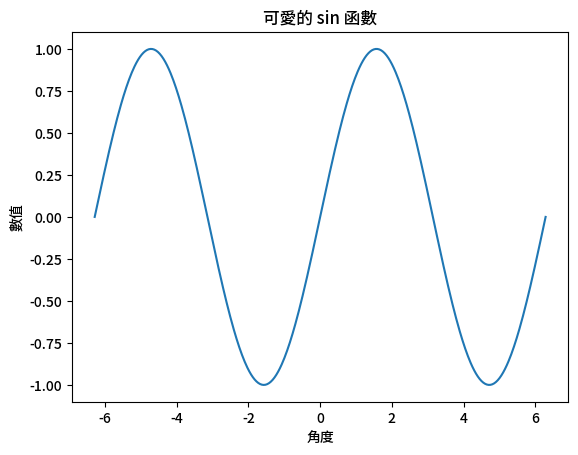

In [4]:
# 快速測試一下中文能不能顯示
x = np.linspace(-2*np.pi, 2*np.pi, 500)
y = np.sin(x)

plt.title('可愛的 sin 函數')
plt.xlabel('角度')
plt.ylabel('數值')
plt.plot(x, y)
plt.show()

### 順便把 Seaborn 請出來(讓圖瞬間變美)

`seaborn` 是基於 matplotlib 的視覺化套件,一行程式就能讓圖變專業。

⚠️ 注意:`sns.set()` 會把字型重設回英文,所以**中文字型要再設一次**。


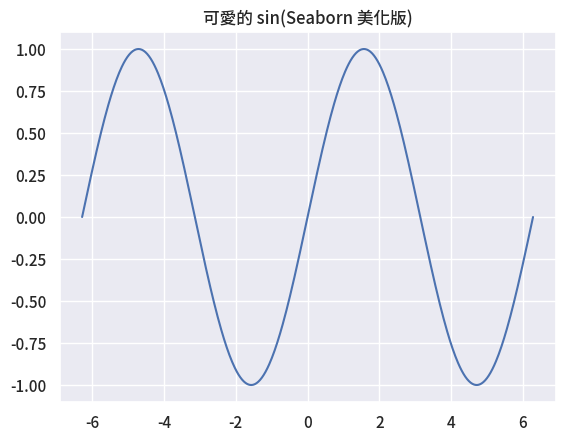

In [5]:
import seaborn as sns
sns.set()

# sns.set() 會重設字型,所以再設一次
mpl.rc('font', family='Noto Sans CJK TC')
mpl.rcParams['axes.unicode_minus'] = False

plt.title('可愛的 sin(Seaborn 美化版)')
plt.plot(x, y)
plt.show()

# 2. Pandas 的兩大主角 🎭

Pandas 裡有兩個最重要的資料型別:

| 主角 | 中文 | 像什麼? |
|------|------|---------|
| `Series` | 一維序列 | Excel 的一欄、Python 的 list 升級版 |
| `DataFrame` | 二維資料表 | 整張 Excel 工作表 |

下面我們一步步來認識它們。


## 2-1. Series:一維資料

`Series` 可以想成一個**有名字的 list**,每個值還有一個「索引」(index)。


In [6]:
# 最簡單的做法:用 list 建立一個 Series
scores = pd.Series([95, 72, 88, 60, 100])
scores

,0
0,95
1,72
2,88
3,60
4,100


看到左邊那欄 `0 1 2 3 4` 了嗎?那就是 **index** (索引)。右邊才是 **值** (values)。

我們也可以自己指定 index 的名字,讓它更有意義:


In [7]:
scores = pd.Series([95, 72, 88, 60, 100],
                   index=['國文', '英文', '數學', '自然', '社會'])
scores

,0
國文,95
英文,72
數學,88
自然,60
社會,100


In [8]:
# 用 index 取值,就像 dict 一樣
scores['數學']

np.int64(88)

In [9]:
# 也可以拿到所有 index 和 values
print('index:', scores.index.tolist())
print('values:', scores.values)

index: ['國文', '英文', '數學', '自然', '社會']
values: [ 95  72  88  60 100]


In [10]:
# Series 的運算會對每個元素做(像 NumPy)
scores + 5   # 每科都加 5 分

,0
國文,100
英文,77
數學,93
自然,65
社會,105


In [11]:
# 統計也超容易
print('平均:', scores.mean())
print('最高:', scores.max())
print('最低:', scores.min())

平均: 83.0
最高: 100
最低: 60


## 2-2. DataFrame:二維資料表

`DataFrame` 就是**把好幾個 Series 拼在一起**,變成一張資料表。

可以這樣想:

- 每一**欄** (column) 是一個 Series
- 每一**列** (row) 是一筆資料
- 兩個軸都有自己的標籤:**column 名稱** 和 **index**


In [12]:
# 用 dict 建立一個 DataFrame(最直覺的方式)
data = {
    '姓名': ['小智', '小霞', '小剛', '小遙', '小光'],
    '年齡': [10, 10, 15, 10, 10],
    '專長': ['電屬性', '水屬性', '岩石屬性', '可愛系', '冰屬性'],
    '徽章數': [8, 4, 8, 5, 8]
}

df = pd.DataFrame(data)
df

,姓名,年齡,專長,徽章數
0,小智,10,電屬性,8
1,小霞,10,水屬性,4
2,小剛,15,岩石屬性,8
3,小遙,10,可愛系,5
4,小光,10,冰屬性,8


### 🔍 看一下這個 DataFrame 的長相

Pandas 提供很多方法讓我們「偷看」一下資料:


In [13]:
df.head(3)   # 看前 3 筆

,姓名,年齡,專長,徽章數
0,小智,10,電屬性,8
1,小霞,10,水屬性,4
2,小剛,15,岩石屬性,8


In [14]:
df.tail(2)   # 看最後 2 筆

,姓名,年齡,專長,徽章數
3,小遙,10,可愛系,5
4,小光,10,冰屬性,8


In [15]:
df.shape    # (列數, 欄數)

(5, 4)

In [16]:
df.columns   # 所有欄位名稱

Index(['姓名', '年齡', '專長', '徽章數'], dtype='object')

In [17]:
df.index     # 列的 index

RangeIndex(start=0, stop=5, step=1)

In [18]:
df.info()    # 每欄的型別、是否有空值

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   姓名      5 non-null      object
 1   年齡      5 non-null      int64 
 2   專長      5 non-null      object
 3   徽章數     5 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 292.0+ bytes


In [19]:
df.describe()   # 只對數值欄位做統計摘要

,年齡,徽章數
count,5.000000,5.000000
mean,11.000000,6.600000
std,2.236068,1.949359
min,10.000000,4.000000
25%,10.000000,5.000000
50%,10.000000,8.000000
75%,10.000000,8.000000
max,15.000000,8.000000


### 🎯 取出一欄 = 一個 Series


In [20]:
df['姓名']   # 單一欄位回傳 Series

,姓名
0,小智
1,小霞
2,小剛
3,小遙
4,小光


In [24]:
type(df['姓名'])   # 確認一下型別

pandas.core.series.Series

In [22]:
# 取好幾欄要用兩層中括號!
df[['姓名', '徽章數']]

,姓名,徽章數
0,小智,8
1,小霞,4
2,小剛,8
3,小遙,5
4,小光,8


### 🎯 用 `loc` 和 `iloc` 取一列

- `loc[index 名稱]`:用**名字**找
- `iloc[位置]`:用**位置**(從 0 開始)找

這兩個的差別,初學者最常搞混,可以問 AI: 「Pandas 的 loc 和 iloc 有什麼不同?什麼時候用哪個?」


In [23]:
# 因為我們沒指定 index,它預設是 0, 1, 2, ...
df.loc[0]     # 用 index 名稱(剛好也是 0)

,0
姓名,小智
年齡,10
專長,電屬性
徽章數,8


In [25]:
df.iloc[0]    # 用位置(第 0 列)

,0
姓名,小智
年齡,10
專長,電屬性
徽章數,8


In [26]:
# 自訂 index,差別就會出現了
df2 = df.set_index('姓名')
df2

,年齡,專長,徽章數
姓名,,,
小智,10,電屬性,8
小霞,10,水屬性,4
小剛,15,岩石屬性,8
小遙,10,可愛系,5
小光,10,冰屬性,8


In [27]:
df2.loc['小剛']    # 用名字找

,小剛
年齡,15
專長,岩石屬性
徽章數,8


In [28]:
df2.iloc[2]        # 用位置找(第 3 個,也就是小剛)

,小剛
年齡,15
專長,岩石屬性
徽章數,8


# 3. 讀真實資料:寶可夢登場! 🔥

接下來要讀一份真實的公開資料——**151 到 721 號寶可夢的能力值**!

資料來源是 GitHub 上一份很有名的公開資料集,包含了每隻寶可夢的:

- 名字、屬性(最多兩種)
- HP、攻擊、防禦、特攻、特防、速度
- 第幾世代、是不是傳說寶可夢


In [29]:
url = 'https://gist.githubusercontent.com/armgilles/194bcff35001e7eb53a2a8b441e8b2c6/raw/92200bc0a673d5ce2110aaad4544ed6c4010f687/pokemon.csv'

poke = pd.read_csv(url)
print('資料大小:', poke.shape)
poke.head()

資料大小: (800, 13)


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


### 📝 第一步:先看看資料長怎樣


In [30]:
poke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [31]:
poke.describe()   # 數值欄位的統計摘要

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


### 🔧 把欄位名字改成中文

原本是英文欄名,我們來改成中文——順便學一下怎麼**改欄位名稱**。

💡 也可以問 AI: 「Pandas 怎麼把 DataFrame 的欄位名稱一次改好幾個?」


In [32]:
poke = poke.rename(columns={
    '#': '編號',
    'Name': '名字',
    'Type 1': '屬性1',
    'Type 2': '屬性2',
    'Total': '總合',
    'HP': 'HP',
    'Attack': '攻擊',
    'Defense': '防禦',
    'Sp. Atk': '特攻',
    'Sp. Def': '特防',
    'Speed': '速度',
    'Generation': '世代',
    'Legendary': '是否傳說'
})
poke.head()

,編號,名字,屬性1,屬性2,總合,HP,攻擊,防禦,特攻,特防,速度,世代,是否傳說
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


# 4. 篩選資料:像布林遮罩

還記得 NumPy 的布林遮罩嗎?Pandas 用的是**一模一樣**的思路。


In [33]:
# 複習 NumPy 的布林遮罩
egg = np.array([-3, 2, -5, 4, 3, 7, 6, -1])
mask = egg > 0
print('遮罩:', mask)
print('留下正數:', egg[mask])

遮罩: [False  True False  True  True  True  True False]
留下正數: [2 4 3 7 6]


In [34]:
# Pandas 的做法完全一樣!
# 找出所有「火」屬性的寶可夢
is_fire = poke['屬性1'] == 'Fire'
poke[is_fire].head()

,編號,名字,屬性1,屬性2,總合,HP,攻擊,防禦,特攻,特防,速度,世代,是否傳說
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False


In [35]:
# 通常我們會寫得更緊湊
poke[poke['屬性1'] == 'Fire'].head()

,編號,名字,屬性1,屬性2,總合,HP,攻擊,防禦,特攻,特防,速度,世代,是否傳說
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False


In [36]:
# 找出攻擊力超過 150 的寶可夢
poke[poke['攻擊'] > 150]

,編號,名字,屬性1,屬性2,總合,HP,攻擊,防禦,特攻,特防,速度,世代,是否傳說
137,127,PinsirMega Pinsir,Bug,Flying,600,65,155,120,65,90,105,1,False
141,130,GyaradosMega Gyarados,Water,Dark,640,95,155,109,70,130,81,1,False
163,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True
232,214,HeracrossMega Heracross,Bug,Fighting,600,80,185,115,40,105,75,2,False
268,248,TyranitarMega Tyranitar,Rock,Dark,700,100,164,150,95,120,71,2,False
279,257,BlazikenMega Blaziken,Fire,Fighting,630,80,160,80,130,80,100,3,False
313,289,Slaking,Normal,NaN,670,150,160,100,95,65,100,3,False
387,354,BanetteMega Banette,Ghost,NaN,555,64,165,75,93,83,75,3,False
424,383,GroudonPrimal Groudon,Ground,Fire,770,100,180,160,150,90,90,3,True
426,384,RayquazaMega Rayquaza,Dragon,Flying,780,105,180,100,180,100,115,3,True


### 🔗 多個條件:用 `&` 和 `|`

⚠️ 注意:

- 要用 `&` (and) 和 `|` (or),**不是** Python 的 `and` / `or`
- 每個條件要**用小括號包起來**

不確定的時候,直接問 AI: 「Pandas 多條件篩選為什麼要用 & 不是 and?」


In [37]:
# 攻擊力 > 100 **且** 速度 > 100 的寶可夢
fast_strong = poke[(poke['攻擊'] > 100) & (poke['速度'] > 100)]
fast_strong.head()

,編號,名字,屬性1,屬性2,總合,HP,攻擊,防禦,特攻,特防,速度,世代,是否傳說
19,15,BeedrillMega Beedrill,Bug,Poison,495,65,150,40,15,80,145,1,False
132,123,Scyther,Bug,Flying,500,70,110,80,55,80,105,1,False
137,127,PinsirMega Pinsir,Bug,Flying,600,65,155,120,65,90,105,1,False
153,142,Aerodactyl,Rock,Flying,515,80,105,65,60,75,130,1,False
154,142,AerodactylMega Aerodactyl,Rock,Flying,615,80,135,85,70,95,150,1,False


In [38]:
# 火屬性 **或** 龍屬性
fire_or_dragon = poke[(poke['屬性1'] == 'Fire') | (poke['屬性1'] == 'Dragon')]
fire_or_dragon.head()

,編號,名字,屬性1,屬性2,總合,HP,攻擊,防禦,特攻,特防,速度,世代,是否傳說
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False


In [39]:
# 想檢查「在不在一個 list 裡」可以用 isin
starters = ['Bulbasaur', 'Charmander', 'Squirtle', 'Pikachu']
poke[poke['名字'].isin(starters)]

,編號,名字,屬性1,屬性2,總合,HP,攻擊,防禦,特攻,特防,速度,世代,是否傳說
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False
30,25,Pikachu,Electric,NaN,320,35,55,40,50,50,90,1,False


# 5. 修改資料表的注意事項 ⚠️

這是 Pandas 最容易踩雷的地方!我們來看幾個重點。


## 5-1. 新增一欄:像 Excel 公式一樣

直接 `df['新欄名'] = 公式`,就會自動對每一列算一次。


In [40]:
# 計算「攻擊力佔總合的比例」
poke['攻擊佔比'] = poke['攻擊'] / poke['總合']
poke[['名字', '攻擊', '總合', '攻擊佔比']].head()

,名字,攻擊,總合,攻擊佔比
0,Bulbasaur,49,318,0.154088
1,Ivysaur,62,405,0.153086
2,Venusaur,82,525,0.156190
3,VenusaurMega Venusaur,100,625,0.160000
4,Charmander,52,309,0.168285


In [41]:
# 新增一個「是否強者」欄位(總合 > 500)
poke['強者'] = poke['總合'] > 500
poke[['名字', '總合', '強者']].head()

,名字,總合,強者
0,Bulbasaur,318,False
1,Ivysaur,405,False
2,Venusaur,525,True
3,VenusaurMega Venusaur,625,True
4,Charmander,309,False


## 5-2. 刪除欄位或列

想問 AI: 「Pandas 怎麼刪除一欄?怎麼刪除一列?」試試看!

最常用的是 `drop`:


In [42]:
# 刪除欄位: axis=1 表示「欄」
# inplace=False(預設)會回傳新 DataFrame,原本的不變
poke_small = poke.drop(columns=['攻擊佔比', '強者'])
poke_small.columns

Index(['編號', '名字', '屬性1', '屬性2', '總合', 'HP', '攻擊', '防禦', '特攻', '特防', '速度',
       '世代', '是否傳說'],
      dtype='object')

In [43]:
# 刪除某幾列: 用 index
# 比如刪掉前 3 筆試試看
poke_no_top3 = poke.drop(index=[0, 1, 2])
poke_no_top3.head()

,編號,名字,屬性1,屬性2,總合,HP,攻擊,防禦,特攻,特防,速度,世代,是否傳說,攻擊佔比,強者
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,0.160000,True
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,0.168285,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False,0.158025,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False,0.157303,True
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False,0.205047,True


## 5-3. ⚠️ 超常見的坑:`SettingWithCopyWarning`

當你先篩選再修改,Pandas 有時分不清你改的是**原本的**還是**副本**,就會跳警告。

**安全作法:先 `.copy()`。**


In [44]:
# ❌ 不推薦的寫法(可能出警告)
# fire = poke[poke['屬性1'] == 'Fire']
# fire['新欄'] = ...     # 這裡 Pandas 會擔心

# ✅ 推薦的寫法
fire = poke[poke['屬性1'] == 'Fire'].copy()
fire['火力等級'] = pd.cut(fire['攻擊'], bins=[0, 50, 100, 200],
                         labels=['小火苗', '火焰', '烈焰'])
fire[['名字', '攻擊', '火力等級']].head()

,名字,攻擊,火力等級
4,Charmander,52,火焰
5,Charmeleon,64,火焰
6,Charizard,84,火焰
7,CharizardMega Charizard X,130,烈焰
8,CharizardMega Charizard Y,104,烈焰


## 5-4. 排序、重設 index

排完序之後,index 會保留原本的順序,看起來亂亂的——這時要**重設 index**。


In [45]:
# 按攻擊力由高到低排
ranking = poke.sort_values(by='攻擊', ascending=False)
ranking.head()

,編號,名字,屬性1,屬性2,總合,HP,攻擊,防禦,特攻,特防,速度,世代,是否傳說,攻擊佔比,強者
163,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True,0.243590,True
232,214,HeracrossMega Heracross,Bug,Fighting,600,80,185,115,40,105,75,2,False,0.308333,True
429,386,DeoxysAttack Forme,Psychic,NaN,600,50,180,20,180,20,150,3,True,0.300000,True
426,384,RayquazaMega Rayquaza,Dragon,Flying,780,105,180,100,180,100,115,3,True,0.230769,True
424,383,GroudonPrimal Groudon,Ground,Fire,770,100,180,160,150,90,90,3,True,0.233766,True


In [46]:
# 看看 index,是亂的!
ranking.head().index

Index([163, 232, 429, 426, 424], dtype='int64')

In [47]:
# reset_index(drop=True) 讓 index 變回 0, 1, 2, ...
ranking = ranking.reset_index(drop=True)
ranking.index = ranking.index + 1   # 從 1 開始當排名
ranking.head(10)

,編號,名字,屬性1,屬性2,總合,HP,攻擊,防禦,特攻,特防,速度,世代,是否傳說,攻擊佔比,強者
1,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True,0.243590,True
2,214,HeracrossMega Heracross,Bug,Fighting,600,80,185,115,40,105,75,2,False,0.308333,True
3,386,DeoxysAttack Forme,Psychic,NaN,600,50,180,20,180,20,150,3,True,0.300000,True
4,384,RayquazaMega Rayquaza,Dragon,Flying,780,105,180,100,180,100,115,3,True,0.230769,True
5,383,GroudonPrimal Groudon,Ground,Fire,770,100,180,160,150,90,90,3,True,0.233766,True
6,646,KyuremBlack Kyurem,Dragon,Ice,700,125,170,100,120,90,95,5,True,0.242857,True
7,445,GarchompMega Garchomp,Dragon,Ground,700,108,170,115,120,95,92,4,False,0.242857,True
8,475,GalladeMega Gallade,Psychic,Fighting,618,68,165,95,65,115,110,4,False,0.266990,True
9,354,BanetteMega Banette,Ghost,NaN,555,64,165,75,93,83,75,3,False,0.297297,True
10,409,Rampardos,Rock,NaN,495,97,165,60,65,50,58,4,False,0.333333,False


## 5-5. 處理遺失值(缺失值) `NaN`

真實資料常常有空的地方,Pandas 用 `NaN` 表示。


In [48]:
# 看看「屬性2」欄有多少空值(沒有第二屬性的寶可夢)
poke['屬性2'].isna().sum()

np.int64(386)

In [49]:
# 把空值補成 '無'
poke['屬性2'] = poke['屬性2'].fillna('無')
poke['屬性2'].value_counts().head()

,count
屬性2,
無,386
Flying,97
Ground,35
Poison,34
Psychic,33


# 6. 分組統計:`groupby` 超好用 🪄

`groupby` 是 Pandas 裡**最強的魔法**之一:

> **「依照某一欄把資料分組,然後對每一組做統計。」**

想問 AI: 「`groupby` 可以舉三個不同的例子嗎?」


In [50]:
# 每種屬性的寶可夢有幾隻?
poke['屬性1'].value_counts()

,count
屬性1,
Water,112
Normal,98
Grass,70
Bug,69
Psychic,57
Fire,52
Rock,44
Electric,44
Ground,32


In [51]:
# 每種屬性的平均攻擊力?
poke.groupby('屬性1')['攻擊'].mean().sort_values(ascending=False)

,攻擊
屬性1,
Dragon,112.125000
Fighting,96.777778
Ground,95.750000
Rock,92.863636
Steel,92.703704
Dark,88.387097
Fire,84.769231
Flying,78.750000
Poison,74.678571


In [52]:
# 一次看多個數值的統計
poke.groupby('屬性1')[['HP', '攻擊', '防禦', '速度']].mean().round(1)

,HP,攻擊,防禦,速度
屬性1,,,,
Bug,56.9,71.0,70.7,61.7
Dark,66.8,88.4,70.2,76.2
Dragon,83.3,112.1,86.4,83.0
Electric,59.8,69.1,66.3,84.5
Fairy,74.1,61.5,65.7,48.6
Fighting,69.9,96.8,65.9,66.1
Fire,69.9,84.8,67.8,74.4
Flying,70.8,78.8,66.2,102.5
Ghost,64.4,73.8,81.2,64.3


In [53]:
# 傳說寶可夢 vs 一般寶可夢比較
poke.groupby('是否傳說')[['總合', '攻擊', '速度']].mean().round(1)

,總合,攻擊,速度
是否傳說,,,
False,417.2,75.7,65.5
True,637.4,116.7,100.2


# 7. 用圖看故事 📊

有了 Pandas + Seaborn,一行程式就能畫出漂亮的圖。


/tmp/ipykernel_2862/464392094.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette='Set3')


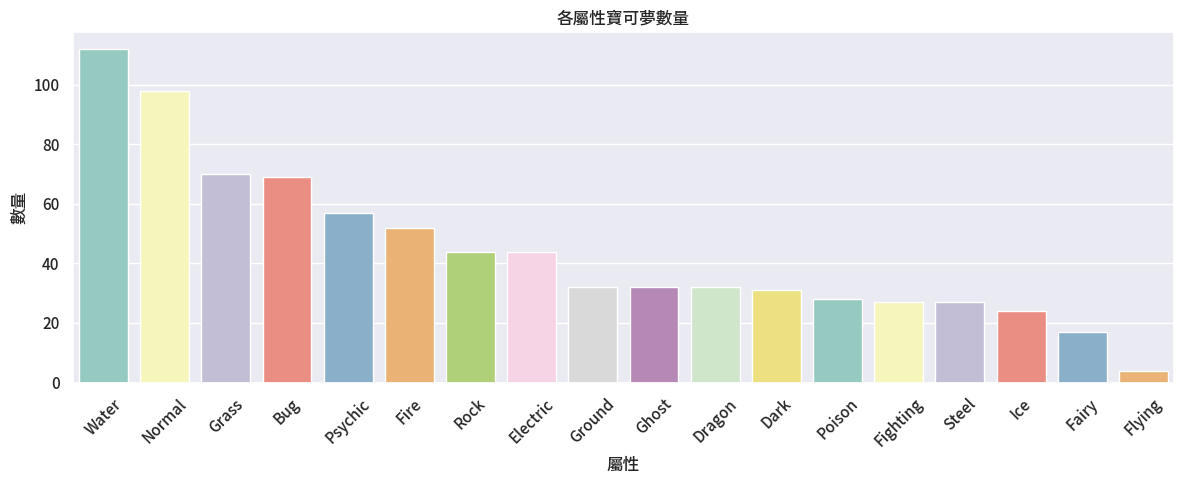

In [54]:
# 每種屬性的寶可夢數量長條圖
plt.figure(figsize=(12, 5))
type_counts = poke['屬性1'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, palette='Set3')
plt.title('各屬性寶可夢數量')
plt.xlabel('屬性')
plt.ylabel('數量')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2862/2032836082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_attack.index, y=avg_attack.values, palette='rocket')


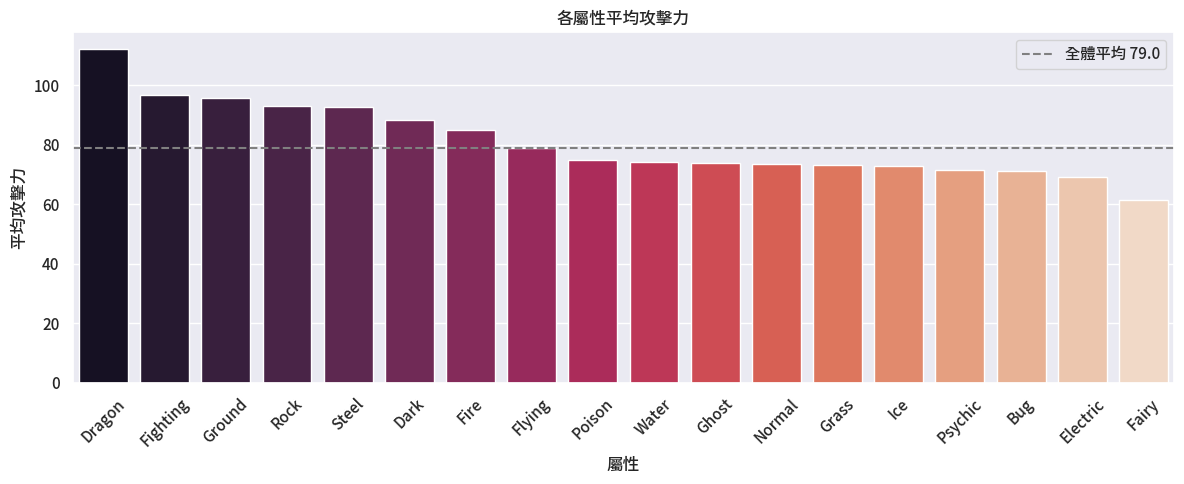

In [55]:
# 各屬性平均攻擊力
avg_attack = poke.groupby('屬性1')['攻擊'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=avg_attack.index, y=avg_attack.values, palette='rocket')
plt.title('各屬性平均攻擊力')
plt.xlabel('屬性')
plt.ylabel('平均攻擊力')
plt.xticks(rotation=45)
plt.axhline(y=poke['攻擊'].mean(), color='gray', linestyle='--',
            label=f'全體平均 {poke["攻擊"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

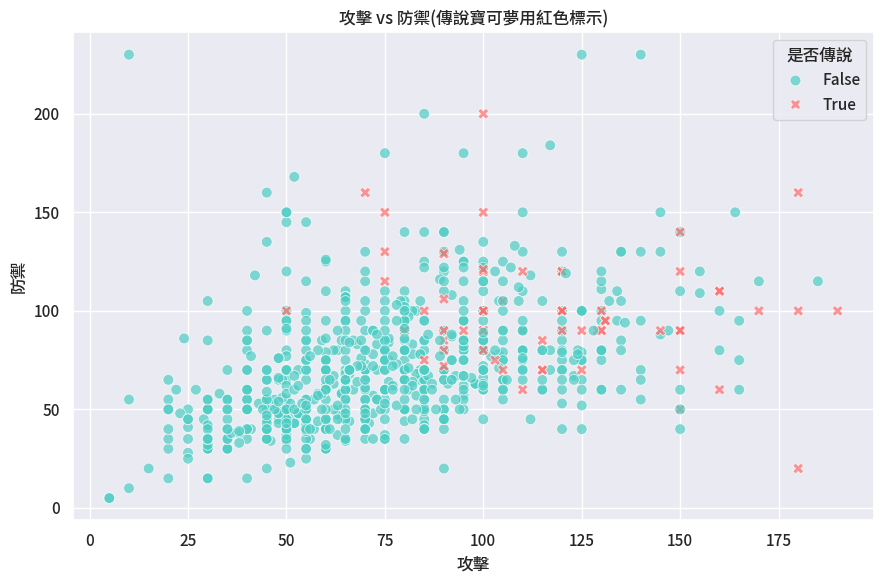

In [56]:
# 攻擊 vs 防禦,用顏色區分是否為傳說
plt.figure(figsize=(9, 6))
sns.scatterplot(data=poke, x='攻擊', y='防禦',
                hue='是否傳說', style='是否傳說',
                s=60, alpha=0.7, palette=['#4ECDC4', '#FF6B6B'])
plt.title('攻擊 vs 防禦(傳說寶可夢用紅色標示)')
plt.tight_layout()
plt.show()

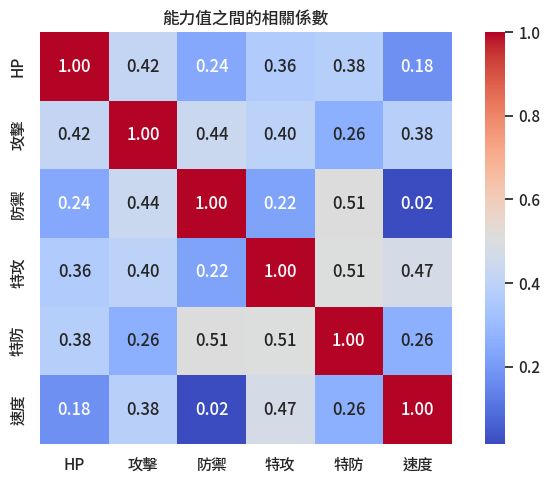

In [57]:
# 六大能力值的相關性熱圖
stats_cols = ['HP', '攻擊', '防禦', '特攻', '特防', '速度']

plt.figure(figsize=(7, 5))
sns.heatmap(poke[stats_cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', square=True)
plt.title('能力值之間的相關係數')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2862/3736475942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=poke, x='是否傳說', y='總合', palette='Set2')


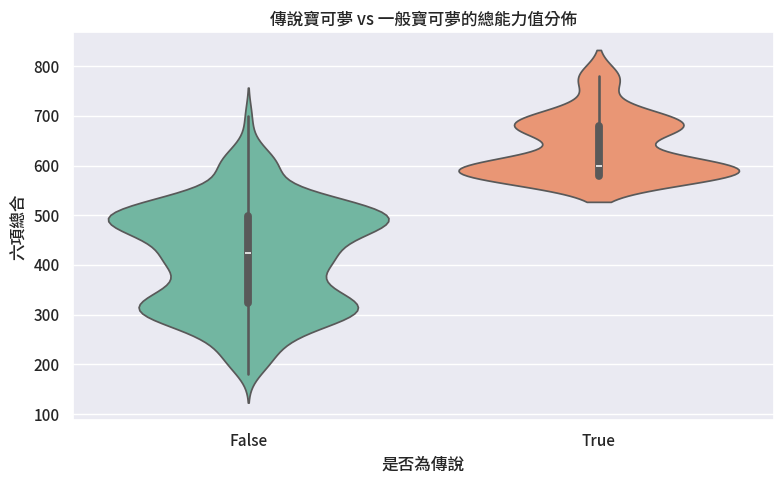

In [58]:
# 小提琴圖:看看傳說 vs 一般的總合分佈
plt.figure(figsize=(8, 5))
sns.violinplot(data=poke, x='是否傳說', y='總合', palette='Set2')
plt.title('傳說寶可夢 vs 一般寶可夢的總能力值分佈')
plt.xlabel('是否為傳說')
plt.ylabel('六項總合')
plt.tight_layout()
plt.show()

# 🎯 AI 協作挑戰

## 挑戰一:組一支夢幻隊伍

**題目:幫我挑出「總合最高的前 6 隻,但每種屬性 1(`屬性1`) 只能出現一次」的寶可夢。**

提示:

- 先用 `sort_values('總合', ascending=False)` 排序
- 用 `drop_duplicates(subset=['屬性1'])` 保留每種屬性的第一隻
- 再 `head(6)`

不知道怎麼做?直接問 AI: **「Pandas 怎麼每個類別只保留最大值的那一筆?」**


In [59]:
# TODO: 試試看!
# 提示:sort_values → drop_duplicates → head

dream_team = (poke.sort_values('總合', ascending=False)
                  .drop_duplicates(subset=['屬性1'])
                  .head(6))

dream_team[['名字', '屬性1', '總合', '攻擊', '防禦', '速度']]

,名字,屬性1,總合,攻擊,防禦,速度
426,RayquazaMega Rayquaza,Dragon,780,180,100,115
163,MewtwoMega Mewtwo X,Psychic,780,190,100,130
422,KyogrePrimal Kyogre,Water,770,150,90,90
424,GroudonPrimal Groudon,Ground,770,180,160,90
552,Arceus,Normal,720,120,120,120
413,MetagrossMega Metagross,Steel,700,145,150,110


## 挑戰二:自己找個問題來玩

挑一個**你真的好奇的問題**,用 Pandas 去回答。例如:

- 哪一隻寶可夢「速度最快,但攻擊墊底」?(玻璃大砲 🥲)
- 水屬性的寶可夢,平均來說防禦比較高還是 HP 比較高?
- 第幾世代的傳說寶可夢最多?

Seaborn 也有很多內建資料集可以玩:

- `sns.load_dataset('titanic')`——鐵達尼號生還
- `sns.load_dataset('penguins')`——企鵝
- `sns.load_dataset('tips')`——餐廳小費

下面是起手式:


In [60]:
# 起手式:載入企鵝資料集玩玩看
penguins = sns.load_dataset('penguins').dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


/tmp/ipykernel_2862/935564881.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins, x='species', y='body_mass_g', palette='Set3')


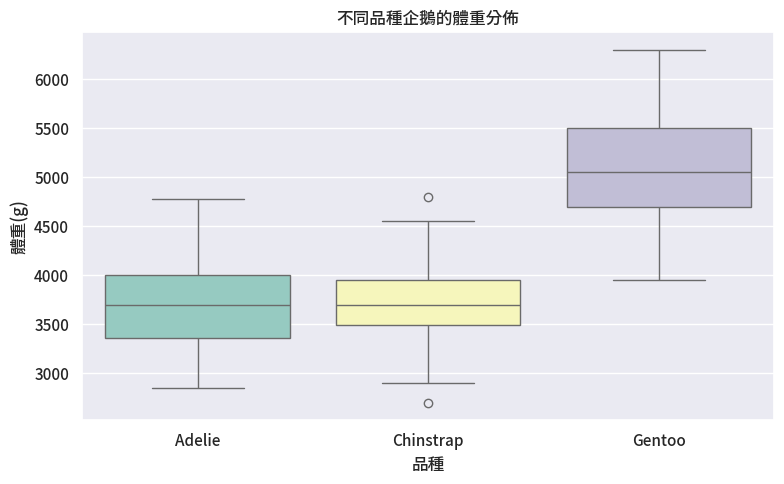

In [61]:
# TODO: 試著回答「不同品種的企鵝,體重分佈有差嗎?」
plt.figure(figsize=(8, 5))
sns.boxplot(data=penguins, x='species', y='body_mass_g', palette='Set3')
plt.title('不同品種企鵝的體重分佈')
plt.xlabel('品種')
plt.ylabel('體重(g)')
plt.tight_layout()
plt.show()

# 🧠 核心觀念回顧

| 我想... | 寫法 |
|---------|------|
| 建立 Series | `pd.Series([...], index=[...])` |
| 建立 DataFrame | `pd.DataFrame({'欄名': [...], ...})` |
| 讀 CSV | `pd.read_csv(url)` |
| 看前幾筆 | `df.head()` / `df.tail()` |
| 資料摘要 | `df.info()` / `df.describe()` |
| 取一欄 | `df['欄名']` |
| 取多欄 | `df[['A', 'B']]` |
| 用名字取一列 | `df.loc[index_name]` |
| 用位置取一列 | `df.iloc[0]` |
| 篩選 | `df[df['欄'] > 值]` |
| 多條件 | `df[(cond1) & (cond2)]` |
| 新增欄 | `df['新欄'] = ...` |
| 刪欄 | `df.drop(columns=['欄'])` |
| 刪列 | `df.drop(index=[0, 1])` |
| 改欄名 | `df.rename(columns={'舊': '新'})` |
| 排序 | `df.sort_values(by='欄')` |
| 重設 index | `df.reset_index(drop=True)` |
| 補 NaN | `df['欄'].fillna(值)` |
| 分組統計 | `df.groupby('欄')['數值欄'].mean()` |
| **遇到不懂的** | **問 AI!** 🤖 |


# 🌟 本週創作任務

找一個**你真的有興趣的問題**,用 Pandas + Seaborn 去回答它。

可以從寶可夢資料繼續延伸,也可以換成自己找的資料集。推薦幾個有趣的方向:

- 🎵 Spotify 流行歌曲特徵——什麼樣的歌容易紅?
- 🍜 Kaggle 的「世界料理食譜」——哪一國的食材最多樣?
- 🎮 Steam 遊戲評價——哪種類型的遊戲評價最兩極?
- 🐦 鳥類或植物圖鑑——分類最多的是哪一科?
- 🏠 區域房價公開資料——但要跨年份小心比較喔

請在報告中回答:

1️⃣ 你想回答的**問題**是什麼?

2️⃣ 資料**從哪裡來**?你做了哪些清理?

3️⃣ 你用了哪些 Pandas **操作**?(篩選/新增欄/groupby/...)

4️⃣ 你**發現**了什麼有趣的事?

5️⃣ 這週你**問了 AI 什麼**?它怎麼幫你的?

祝你玩得開心!✨
